# Formula 1 Safety Car hazard probability model

This notebook predicts, after every completed lap, the probability of a **new** Safety Car (SC) start within the next 1, 3, 5, and 10 laps. It uses only information available by the prediction lap and replays each race in order.

The target is `SC_START`, not SC-active laps. TrackStatus code `4` denotes SC; code `6` denotes VSC. Consecutive active laps form one event.

## Design

For a race state at lap $t$, the discrete hazard model estimates $h(t+k)$ for future laps. Cumulative probabilities are derived as $1 - \prod_{k=1}^{n}(1-h(t+k))$, so the four reported windows are naturally monotonic.

The notebook intentionally does not implement the final Race State Manager. `build_race_laps` is a temporary adapter from raw driver-lap CSVs to the contract the future manager should supply: one causal race-state row per completed lap.

In [1]:
from pathlib import Path
from functools import reduce
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, log_loss,
                             roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
HORIZONS = (1, 3, 5, 10)
MAX_HORIZON = max(HORIZONS)
DEFAULT_SCHEDULED_LAPS = 60  # used only until the Race State Manager provides an official lap plan
DATA_DIR = Path('data_fastf1_v1/laps')
assert DATA_DIR.exists(), f'Missing data directory: {DATA_DIR.resolve()}'
sns.set_theme(style='whitegrid', context='notebook')

## Load raw data

Each CSV is driver-lap level. `race_id` is stable across the notebook and races are kept in season/round order for all splits. Use `years` or `max_races` while iterating locally; set both to `None` for the complete data set.

In [2]:
def load_raw_laps(data_dir=DATA_DIR, years=None, max_races=None):
    files = sorted(data_dir.glob('*/*.csv'))
    if years is not None:
        allowed = {str(y) for y in years}
        files = [p for p in files if p.parent.name in allowed]
    if max_races is not None:
        files = files[:max_races]
    frames = []
    for path in files:
        df = pd.read_csv(path, low_memory=False)
        if df.empty or 'LapNumber' not in df:
            continue
        df['race_id'] = f"{int(df['Year'].iloc[0])}_{int(df['Round'].iloc[0]):02d}"
        df['race_name'] = df['GrandPrix'].iloc[0]
        frames.append(df)
    if not frames:
        raise FileNotFoundError('No usable FastF1 race CSVs found.')
    return pd.concat(frames, ignore_index=True)

# Start with all available races. For a quick smoke test, use years=[2021].
raw_laps = load_raw_laps()
print(f'{raw_laps.race_id.nunique()} races, {len(raw_laps):,} driver-lap rows')
raw_laps[['race_id', 'race_name', 'Year', 'Round']].drop_duplicates().head()

172 races, 188,482 driver-lap rows


,race_id,race_name,Year,Round
0,2018_21,Abu Dhabi Grand Prix,2018,21
943,2018_01,Australian Grand Prix,2018,1
1883,2018_09,Austrian Grand Prix,2018,9
3127,2018_04,Azerbaijan Grand Prix,2018,4
3975,2018_02,Bahrain Grand Prix,2018,2


## Track-status decoding and causal race state

FastF1 can encode simultaneous statuses as concatenated digits, so status checks are string-based. A race-level lap is created before event detection, preventing one SC from being counted once per driver. Feature values are aggregates of data at or before that lap only.

In [3]:
def has_status(status):
    return str(int(float(status))) if pd.notna(status) else ''

def status_contains(status, code):
    return str(code) in has_status(status, code)

def first_valid(series):
    series = series.dropna()
    return series.iloc[0] if len(series) else np.nan

def build_race_laps(driver_laps):
    df = driver_laps.copy()
    df = df[df['LapNumber'].notna() & (df['LapNumber'] > 0)].copy()
    df['lap'] = df['LapNumber'].astype(int)
    df['track_status_text'] = df['TrackStatus'].map(has_status)
    df['sc_driver'] = df['track_status_text'].str.contains('4', regex=False)
    df['vsc_driver'] = df['track_status_text'].str.contains('6', regex=False)
    # Deleted laps are usually track-limit/penalty deletions, not retirements. Keep them correctly labelled.
    df['deleted_driver_lap'] = df.get('Deleted', False).fillna(False).astype(bool)

    agg = df.groupby(['race_id', 'lap'], as_index=False).agg(
        year=('Year', 'first'), round=('Round', 'first'), circuit=('Location', 'first'),
        race_name=('race_name', 'first'), active_cars=('Driver', 'nunique'),
        sc_active=('sc_driver', 'max'), vsc_active=('vsc_driver', 'max'),
        deleted_laps=('deleted_driver_lap', 'sum'), pit_stops_lap=('PitInTimeSeconds', lambda s: s.notna().sum()),
        median_lap_time=('LapTimeSeconds', 'median'), lap_time_std=('LapTimeSeconds', 'std'), median_s1=('Sector1TimeSeconds', 'median'),
        median_s2=('Sector2TimeSeconds', 'median'), median_s3=('Sector3TimeSeconds', 'median'),
        median_gap_ahead=('IntervalToPositionAheadSeconds', 'median'),
        gap_iqr=('GapToLeaderSeconds', lambda s: s.quantile(.75) - s.quantile(.25)),
        speed_trap_coverage=('SpeedST', lambda s: s.notna().mean()),
        median_tyre_life=('TyreLife', 'median'), fresh_tyre_rate=('FreshTyre', 'mean'),
        rainfall=('Rainfall', 'max'), air_temp=('AirTemp', 'median'), humidity=('Humidity', 'median'), track_temp=('TrackTemp', 'median'),
        wind_speed=('WindSpeed', 'median')
    )
    agg = agg.sort_values(['race_id', 'lap']).reset_index(drop=True)
    by_race = agg.groupby('race_id', group_keys=False)
    # Diagnostic only: never use final observed lap count as an input feature.
    agg['observed_race_laps'] = by_race['lap'].transform('max')
    agg['sc_start'] = agg['sc_active'] & ~by_race['sc_active'].shift(fill_value=False)
    agg['vsc_start'] = agg['vsc_active'] & ~by_race['vsc_active'].shift(fill_value=False)
    agg['previous_sc_count'] = by_race['sc_start'].cumsum() - agg['sc_start'].astype(int)
    agg['previous_vsc_count'] = by_race['vsc_start'].cumsum() - agg['vsc_start'].astype(int)
    agg['deleted_laps_so_far'] = by_race['deleted_laps'].cumsum()
    agg['recent_deleted_laps_5'] = by_race['deleted_laps'].transform(lambda s: s.rolling(5, min_periods=1).sum())
    agg['total_pits'] = by_race['pit_stops_lap'].cumsum()
    agg['pits_last3'] = by_race['pit_stops_lap'].transform(lambda s: s.rolling(3, min_periods=1).sum())
    agg['rainfall_flag'] = agg['rainfall'].fillna(0).gt(0).astype(int)
    agg['laps_since_sc'] = by_race['sc_start'].transform(lambda s: (~s).groupby(s.cumsum()).cumcount() + 1)
    agg['laps_since_vsc'] = by_race['vsc_start'].transform(lambda s: (~s).groupby(s.cumsum()).cumcount() + 1)
    agg['pace_abnormality'] = by_race['median_lap_time'].transform(lambda s: s / s.rolling(5, min_periods=2).median() - 1)
    return agg

def attach_causal_lap_plan(race_laps, default_laps=DEFAULT_SCHEDULED_LAPS):
    """Create a pre-race lap-plan proxy without using the current race's final lap count.

    The eventual Race State Manager should replace `planned_race_laps` with the official
    scheduled-lap value. Until then, use only completed *earlier* races at the same circuit.
    """
    out = race_laps.copy()
    races = (out[['race_id', 'year', 'round', 'circuit', 'observed_race_laps']]
             .drop_duplicates().sort_values(['year', 'round']).reset_index(drop=True))
    prior_by_circuit, prior_all, plans, sources = {}, [], {}, {}
    for race in races.itertuples(index=False):
        circuit_history = prior_by_circuit.get(race.circuit, [])
        if circuit_history:
            plan, source = int(round(np.median(circuit_history))), 'prior_circuit_median'
        elif prior_all:
            plan, source = int(round(np.median(prior_all))), 'prior_global_median'
        else:
            plan, source = default_laps, 'default'
        plans[race.race_id], sources[race.race_id] = plan, source
        # This value becomes available only after this race has finished, for later races.
        prior_by_circuit.setdefault(race.circuit, []).append(race.observed_race_laps)
        prior_all.append(race.observed_race_laps)
    out['planned_race_laps'] = out.race_id.map(plans).clip(lower=1)
    out['lap_plan_source'] = out.race_id.map(sources)
    out['race_progress'] = (out.lap / out.planned_race_laps).clip(upper=1)
    return out

race_laps = attach_causal_lap_plan(build_race_laps(raw_laps))
race_laps[['race_id', 'lap', 'sc_active', 'sc_start', 'vsc_active', 'vsc_start']].head()

,race_id,lap,sc_active,sc_start,vsc_active,vsc_start
0,2018_01,1,False,False,False,False
1,2018_01,2,False,False,False,False
2,2018_01,3,False,False,False,False
3,2018_01,4,False,False,False,False
4,2018_01,5,False,False,False,False


## Validation of event decoding

Abu Dhabi and Italian 2021 are intentionally inspected as known-case tests. This validates decoder behaviour and target construction only; it is not a final performance sample.

,race_name,lap,sc_active,sc_start,vsc_active,vsc_start
4282,Italian Grand Prix,1,False,False,True,True
4306,Italian Grand Prix,25,True,True,False,False
4323,Italian Grand Prix,42,False,False,True,True
4784,Abu Dhabi Grand Prix,34,False,False,True,True
4801,Abu Dhabi Grand Prix,51,True,True,False,False


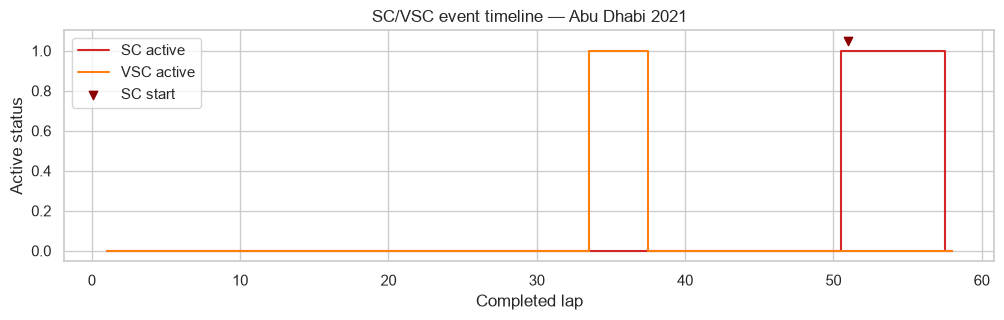

In [4]:
validation_cases = race_laps.query("year == 2021 and race_name.isin(['Abu Dhabi Grand Prix', 'Italian Grand Prix'])")
display(validation_cases.loc[validation_cases.sc_start | validation_cases.vsc_start,
    ['race_name', 'lap', 'sc_active', 'sc_start', 'vsc_active', 'vsc_start']])

fig, ax = plt.subplots(figsize=(12, 3))
case = validation_cases[validation_cases.race_name.eq('Abu Dhabi Grand Prix')]
ax.step(case.lap, case.sc_active.astype(int), where='mid', label='SC active', color='tab:red')
ax.step(case.lap, case.vsc_active.astype(int), where='mid', label='VSC active', color='tab:orange')
ax.scatter(case.loc[case.sc_start, 'lap'], [1.05] * case.sc_start.sum(), marker='v', color='darkred', label='SC start')
ax.set(title='SC/VSC event timeline — Abu Dhabi 2021', xlabel='Completed lap', ylabel='Active status'); ax.legend(); plt.show()

## Future targets, chronological split, and historical baselines

At lap $t$, `target_h1` is whether an SC begins at $t+1`; broader targets identify a start in the relevant future window. Rows without a complete horizon are excluded only from that horizon’s evaluation. Race-level chronological splitting prevents leakage across laps from the same race. Baselines are fit on training races only with smoothing.

In [5]:
def add_future_targets(df, horizons=HORIZONS):
    out = df.copy().sort_values(['race_id', 'lap'])
    for horizon in horizons:
        future = out.groupby('race_id')['sc_start'].transform(
            lambda s: s.iloc[::-1].rolling(horizon, min_periods=horizon).max().iloc[::-1].shift(-1)
        )
        out[f'target_{horizon}'] = future
    out['target_h1'] = out['target_1']
    return out

def chronological_race_split(df, train=.60, validation=.20):
    races = df[['race_id', 'year', 'round']].drop_duplicates().sort_values(['year', 'round'])['race_id'].tolist()
    a, b = int(len(races) * train), int(len(races) * (train + validation))
    return races[:a], races[a:b], races[b:]

def fit_progress_baseline(train, circuit_aware=False, bins=10, smoothing=5):
    x = train.dropna(subset=['target_1']).copy()
    x['progress_bin'] = pd.cut(x.race_progress, bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    keys = ['progress_bin'] + (['circuit'] if circuit_aware else [])
    global_rate = x.target_1.mean()
    table = x.groupby(keys, observed=True).target_1.agg(['sum', 'count']).reset_index()
    table['hazard'] = (table['sum'] + smoothing * global_rate) / (table['count'] + smoothing)
    return table[keys + ['hazard']], global_rate, keys

def predict_baseline(df, fitted):
    table, global_rate, keys = fitted
    x = df.copy(); x['progress_bin'] = pd.cut(x.race_progress, bins=np.linspace(0, 1, 11), include_lowest=True)
    x = x.merge(table, on=keys, how='left')
    return x.hazard.fillna(global_rate).to_numpy()

race_laps = add_future_targets(race_laps)
train_ids, val_ids, test_ids = chronological_race_split(race_laps)
train = race_laps[race_laps.race_id.isin(train_ids)].copy()
val = race_laps[race_laps.race_id.isin(val_ids)].copy()
test = race_laps[race_laps.race_id.isin(test_ids)].copy()
progress_baseline = fit_progress_baseline(train)
circuit_progress_baseline = fit_progress_baseline(train, circuit_aware=True)
print(f'Train/validation/test races: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}')

Train/validation/test races: 103/34/35


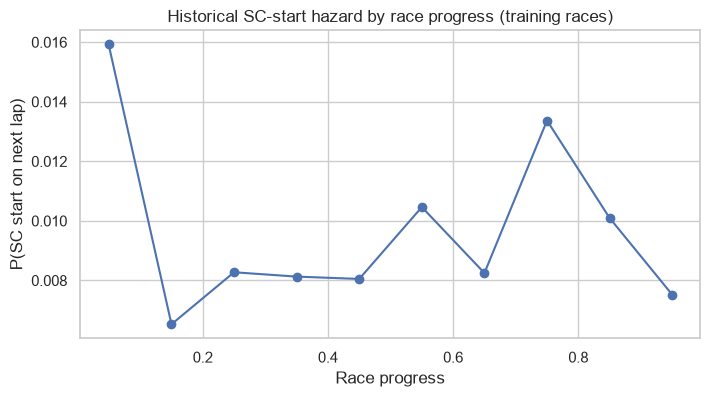

In [6]:
# Historical probability by race progress (training data only)
plot_base = progress_baseline[0].copy()
plot_base['progress_midpoint'] = plot_base.progress_bin.map(lambda x: x.mid)
plt.figure(figsize=(8, 4))
plt.plot(plot_base.progress_midpoint, plot_base.hazard, marker='o')
plt.title('Historical SC-start hazard by race progress (training races)')
plt.xlabel('Race progress'); plt.ylabel('P(SC start on next lap)'); plt.show()

## History-aware discrete-time hazard model

The model is a pooled landmark discrete-time hazard model. Each observed state at lap $t$ is expanded into at-risk rows for offsets $k=1,\ldots,10$, then the model learns $h(t+k \mid \mathrm{RaceState}_t, k)$. It therefore estimates distinct hazards for each future lap instead of repeating the next-lap probability. No SMOTE is used: synthetic future-state rows are not appropriate for this time-ordered, rare-event task.

This is history-aware through causal cumulative/rolling state features, but it is not a recurrent neural sequence model. A future recurrent/transformer model can preserve the `predict_offset_hazards` interface.

In [7]:
NUMERIC_FEATURES = ['lap', 'race_progress', 'active_cars', 'previous_sc_count',
    'previous_vsc_count', 'laps_since_sc', 'laps_since_vsc', 'deleted_laps_so_far',
    'recent_deleted_laps_5', 'median_gap_ahead', 'gap_iqr', 'speed_trap_coverage',
    'median_lap_time', 'median_s1', 'median_s2', 'median_s3', 'pace_abnormality',
    'median_tyre_life', 'fresh_tyre_rate', 'rainfall', 'air_temp', 'humidity', 'track_temp', 'wind_speed']
CATEGORICAL_FEATURES = ['circuit']
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

HAZARD_NUMERIC_FEATURES = NUMERIC_FEATURES + ['forecast_offset', 'forecast_progress']
HAZARD_FEATURES = HAZARD_NUMERIC_FEATURES + CATEGORICAL_FEATURES

def make_landmark_hazard_rows(states, max_horizon=MAX_HORIZON, with_targets=True):
    """Expand state at t into an at-risk row for each future offset k.

    In training, rows after the first future SC start are removed from the risk set.
    In serving, all requested offsets are scored from the information available at t.
    """
    records = []
    for race_id, race in states.sort_values(['race_id', 'lap']).groupby('race_id'):
        race = race.reset_index(drop=True)
        by_lap = race.set_index('lap')['sc_start'].to_dict()
        final_observed_lap = int(race.lap.max())
        for row in race.itertuples(index=False):
            state_key = f'{race_id}::{row.lap}'
            for offset in range(1, max_horizon + 1):
                future_lap = row.lap + offset
                if with_targets and future_lap > final_observed_lap:
                    break
                record = {feature: getattr(row, feature) for feature in FEATURES}
                record.update({'state_key': state_key, 'race_id': race_id, 'lap': row.lap,
                               'forecast_offset': offset,
                               'forecast_progress': min(1.0, future_lap / row.planned_race_laps)})
                if with_targets:
                    event = int(bool(by_lap.get(future_lap, False)))
                    record['event_on_offset'] = event
                    records.append(record)
                    if event:
                        break
                else:
                    records.append(record)
    return pd.DataFrame(records)

def make_hazard_model():
    prep = ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), HAZARD_NUMERIC_FEATURES),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL_FEATURES)
    ])
    return Pipeline([('prep', prep), ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))])

train_hazards = make_landmark_hazard_rows(train)
val_hazards = make_landmark_hazard_rows(val)
hazard_model = make_hazard_model().fit(train_hazards[HAZARD_FEATURES], train_hazards.event_on_offset)
# Platt scaling keeps a smooth calibration mapping; fitting uses later, race-disjoint validation data only.
val_raw = hazard_model.predict_proba(val_hazards[HAZARD_FEATURES])[:, 1]
val_logit = np.log(np.clip(val_raw, 1e-6, 1 - 1e-6) / np.clip(1 - val_raw, 1e-6, 1))
calibrator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(val_logit.reshape(-1, 1), val_hazards.event_on_offset)

def predict_offset_hazards(states):
    """Return h(t+k | RaceState_t) for k=1,...,10 without inspecting future race rows."""
    future_states = make_landmark_hazard_rows(states, with_targets=False)
    raw = hazard_model.predict_proba(future_states[HAZARD_FEATURES])[:, 1]
    logits = np.log(np.clip(raw, 1e-6, 1 - 1e-6) / np.clip(1 - raw, 1e-6, 1))
    future_states['hazard'] = calibrator.predict_proba(logits.reshape(-1, 1))[:, 1]
    wide = future_states.pivot(index='state_key', columns='forecast_offset', values='hazard')
    wide = wide.reindex(columns=range(1, MAX_HORIZON + 1)).rename(columns=lambda k: f'hazard_{k}')
    return states.assign(state_key=states.race_id.astype(str) + '::' + states.lap.astype(str)).merge(wide, left_on='state_key', right_index=True, how='left')

test = predict_offset_hazards(test)
test['hazard_progress'] = predict_baseline(test, progress_baseline)
test['hazard_circuit_progress'] = predict_baseline(test, circuit_progress_baseline)

## Chronological replay and multi-horizon probabilities

At real lap $t$, future state features are unknown. The replay scores each offset from the observed state at $t$, its forecast offset, and deterministic planned race progress. It does not inspect future race rows; a future state-transition simulator can improve these forecasts without changing the output schema.

In [8]:
def offset_baseline_hazards(states, fitted):
    """Historical h(t+k) using deterministic planned progress at each offset."""
    output = pd.DataFrame(index=states.index)
    for offset in range(1, MAX_HORIZON + 1):
        future = states.copy()
        future['race_progress'] = ((future.lap + offset) / future.planned_race_laps).clip(upper=1)
        output[f'hazard_{offset}'] = predict_baseline(future, fitted)
    return output

def hazards_to_windows(hazard_rows, horizons=HORIZONS):
    hazards = hazard_rows[[f'hazard_{k}' for k in range(1, MAX_HORIZON + 1)]].to_numpy(dtype=float)
    hazards = np.clip(hazards, 0, 1)
    return {f'P_SC_{n}': 1 - np.prod(1 - hazards[:, :n], axis=1) for n in horizons}

def replay_race(race_states):
    # Serving order: reveal RaceState_t, score all future offsets, store, then reveal t+1.
    race_states = race_states.sort_values('lap').copy()
    output = race_states[['race_id', 'lap']].copy()
    output['hazard_next_lap'] = race_states.hazard_1
    for name, values in hazards_to_windows(race_states).items():
        output[name] = values
    for n in HORIZONS:
        output[f'actual_SC_within_{n}'] = race_states[f'target_{n}'].to_numpy()
    return output

for probability_name, probability_values in hazards_to_windows(test).items():
    test[probability_name] = probability_values
predictions = pd.concat([replay_race(g) for _, g in test.groupby('race_id')], ignore_index=True)
assert (predictions.P_SC_1 <= predictions.P_SC_3).all()
assert (predictions.P_SC_3 <= predictions.P_SC_5).all()
assert (predictions.P_SC_5 <= predictions.P_SC_10).all()
predictions.head()

,race_id,lap,hazard_next_lap,P_SC_1,P_SC_3,P_SC_5,P_SC_10,actual_SC_within_1,actual_SC_within_3,actual_SC_within_5,actual_SC_within_10
0,2024_14,1,0.010158,0.010158,0.030242,0.050018,0.098124,0.0,0.0,0.0,0.0
1,2024_14,2,0.010243,0.010243,0.030491,0.050425,0.098903,0.0,0.0,0.0,0.0
2,2024_14,3,0.010100,0.010100,0.030071,0.049737,0.097587,0.0,0.0,0.0,0.0
3,2024_14,4,0.010045,0.010045,0.029908,0.049470,0.097078,0.0,0.0,0.0,0.0
4,2024_14,5,0.010102,0.010102,0.030076,0.049745,0.097602,0.0,0.0,0.0,0.0


## Evaluation and comparison

Metrics are calculated only on rows with a fully observable future horizon. The notebook also loads the existing saved XGBoost trigger model when its model artifacts are available; it is a benchmark, not the preferred serving model.

In [9]:
def safe_metric(metric, y, p):
    return metric(y, p) if pd.Series(y).nunique() == 2 else np.nan

def score_probabilities(df, probability_column, target_column='target_1'):
    x = df.dropna(subset=[target_column, probability_column])
    y, p = x[target_column].astype(int), x[probability_column].clip(1e-6, 1 - 1e-6)
    return {'Brier': brier_score_loss(y, p), 'Log loss': log_loss(y, p),
            'PR-AUC': safe_metric(average_precision_score, y, p), 'ROC-AUC': safe_metric(roc_auc_score, y, p)}

comparison = pd.DataFrame({
    'Historical progress': score_probabilities(test, 'hazard_progress'),
    'Circuit + progress': score_probabilities(test, 'hazard_circuit_progress'),
    'Offset-specific hazard': score_probabilities(test, 'hazard_1')
}).T
display(comparison.sort_values('Brier'))

# Existing XGBoost trigger model comparison (optional; no refit and no access to held-out labels).
try:
    import joblib
    model_path = Path('models/sc_trigger_xgboost.joblib')
    calibration_path = Path('models/sc_trigger_calibrator.joblib')
    feature_path = Path('models/sc_trigger_features.joblib')
    if not all(p.exists() for p in (model_path, calibration_path, feature_path)):
        raise FileNotFoundError('Saved XGBoost artifacts are not present.')
    xgb_features = joblib.load(feature_path)
    xgb_input = pd.DataFrame({
        'LapNumber': test.lap, 'race_progress': test.race_progress,
        'tyre_age_med': test.median_tyre_life, 'lap_time_std': test.lap_time_std,
        # Retirement status is unavailable in the raw lap feed; do not substitute Deleted-lap penalties.
        'retirements': 0, 'total_pits': test.total_pits, 'pits_last3': test.pits_last3,
        'track_temp': test.track_temp, 'air_temp': test.air_temp, 'humidity': test.humidity,
        'rainfall_flag': test.rainfall_flag, 'sc_count_prev': test.previous_sc_count,
        'laps_since_last_sc': test.laps_since_sc, 'n_cars': test.active_cars
    }, index=test.index).reindex(columns=xgb_features).replace([np.inf, -np.inf], np.nan).fillna(0)
    existing_xgb = joblib.load(model_path)
    existing_xgb_calibrator = joblib.load(calibration_path)
    raw_xgb = existing_xgb.predict_proba(xgb_input)[:, 1]
    test['hazard_xgboost'] = np.asarray(existing_xgb_calibrator.predict(raw_xgb)).reshape(-1)
    comparison.loc['Existing XGBoost'] = score_probabilities(test, 'hazard_xgboost')
    display(comparison.sort_values('Brier'))
except (ImportError, FileNotFoundError) as exc:
    print(f'Existing XGBoost comparison skipped: {exc}')

# Evaluate every requested cumulative horizon against its matching observed target.
progress_hazards = offset_baseline_hazards(test, progress_baseline)
circuit_hazards = offset_baseline_hazards(test, circuit_progress_baseline)
for label, hazards in [('progress', progress_hazards), ('circuit_progress', circuit_hazards)]:
    for probability_name, values in hazards_to_windows(hazards).items():
        test[f'{label}_{probability_name}'] = values

window_rows = []
for horizon in HORIZONS:
    target = f'target_{horizon}'
    for label, column in {
        'Historical progress': f'progress_P_SC_{horizon}',
        'Circuit + progress': f'circuit_progress_P_SC_{horizon}',
        'Offset-specific hazard': f'P_SC_{horizon}'
    }.items():
        window_rows.append({'Horizon': horizon, 'Model': label, **score_probabilities(test.assign(probability=test[column]), 'probability', target)})
window_comparison = pd.DataFrame(window_rows).set_index(['Horizon', 'Model'])
display(window_comparison.round(5))

,Brier,Log loss,PR-AUC,ROC-AUC
Historical progress,0.007734,0.045402,0.011090,0.628791
Offset-specific hazard,0.007736,0.045569,0.009784,0.565907
Circuit + progress,0.008065,0.053895,0.008159,0.474352


,Brier,Log loss,PR-AUC,ROC-AUC
Historical progress,0.007734,0.045402,0.011090,0.628791
Offset-specific hazard,0.007736,0.045569,0.009784,0.565907
Existing XGBoost,0.007742,0.045781,0.008026,0.484344
Circuit + progress,0.008065,0.053895,0.008159,0.474352


Brier  Log loss   PR-AUC  ROC-AUC
Horizon Model                                                      
1       Historical progress     0.00773   0.04517  0.01220  0.62328
        Circuit + progress      0.00806   0.05404  0.00799  0.45951
        Offset-specific hazard  0.00774   0.04557  0.00978  0.56591
3       Historical progress     0.02171   0.10628  0.03039  0.60790
        Circuit + progress      0.02409   0.13245  0.02093  0.43676
        Offset-specific hazard  0.02172   0.10665  0.02452  0.55382
5       Historical progress     0.03620   0.15984  0.04865  0.59185
        Circuit + progress      0.04175   0.20473  0.03299  0.42118
        Offset-specific hazard  0.03629   0.16078  0.03883  0.53617
10      Historical progress     0.06966   0.26689  0.09532  0.57683
        Circuit + progress      0.08365   0.34407  0.06514  0.43153
        Offset-specific hazard  0.06991   0.26819  0.07504  0.52699

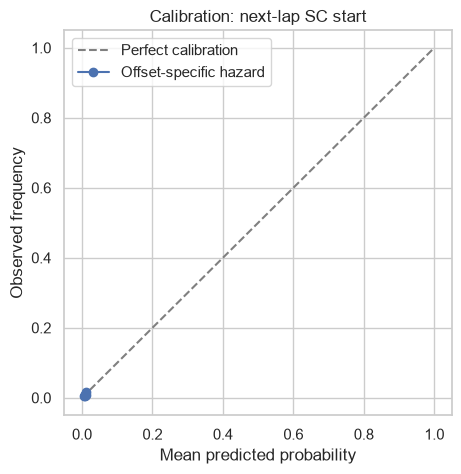

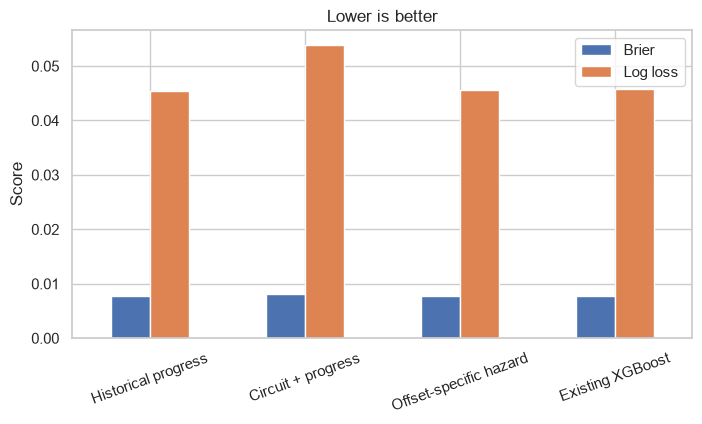

In [10]:
# Calibration/reliability curve for the primary next-lap model
eval_rows = test.dropna(subset=['target_1', 'hazard_1'])
observed, predicted = calibration_curve(eval_rows.target_1.astype(int), eval_rows.hazard_1, n_bins=8, strategy='quantile')
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
ax.plot(predicted, observed, marker='o', label='Offset-specific hazard')
ax.set(xlabel='Mean predicted probability', ylabel='Observed frequency', title='Calibration: next-lap SC start'); ax.legend(); plt.show()

# Model comparison, emphasizing proper scoring rather than accuracy.
comparison[['Brier', 'Log loss']].plot.bar(figsize=(8, 4), rot=20, title='Lower is better')
plt.ylabel('Score'); plt.show()

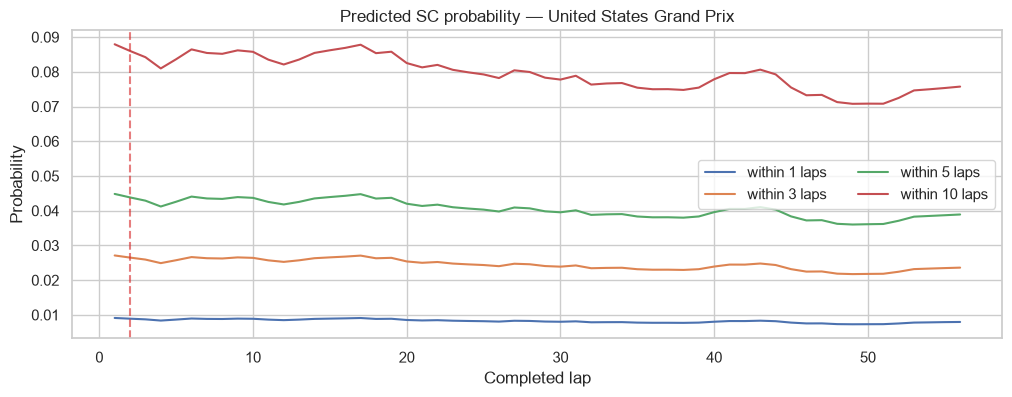

,race_id,lap,P_SC_1,P_SC_3,P_SC_5,P_SC_10,sc_start
0,2024_19,1,0.009107,0.027107,0.044828,0.087926,False
1,2024_19,2,0.008899,0.026495,0.043824,0.086001,True


In [11]:
# Pick a held-out race with an SC start, then inspect predictions around it.
test_events = test.groupby('race_id').sc_start.sum()
example_race_id = test_events[test_events.gt(0)].index[0]
example = predictions[predictions.race_id.eq(example_race_id)].merge(
    test[['race_id', 'lap', 'race_name', 'sc_start']], on=['race_id', 'lap'], how='left')
fig, ax = plt.subplots(figsize=(12, 4))
for n in HORIZONS:
    ax.plot(example.lap, example[f'P_SC_{n}'], label=f'within {n} laps')
for lap in example.loc[example.sc_start, 'lap']:
    ax.axvline(lap, color='tab:red', alpha=.6, linestyle='--')
ax.set(title=f'Predicted SC probability — {example.race_name.iloc[0]}', xlabel='Completed lap', ylabel='Probability')
ax.legend(ncol=2); plt.show()

event_lap = int(example.loc[example.sc_start, 'lap'].iloc[0])
display(example.loc[example.lap.between(max(1, event_lap - 8), event_lap),
    ['race_id', 'lap', 'P_SC_1', 'P_SC_3', 'P_SC_5', 'P_SC_10', 'sc_start']])

## Handoff

`predictions` has the serving/evaluation schema: `race_id`, `lap`, `P_SC_1`, `P_SC_3`, `P_SC_5`, `P_SC_10`, plus actual future-event columns. Save it only after model selection, then load the calibrated hazard model alongside the future Race State Manager for Monte Carlo simulation.

Limitations: `planned_race_laps` is currently a causal historical proxy until the Race State Manager provides the official pre-race lap plan; retirement status is unavailable in this raw feed and is therefore not fabricated from deleted laps; early-stop/lap-completeness is handled by missing targets; and the two 2021 validation races validate logic rather than generalisation. SC duration is deliberately out of scope.